In [1]:
%load_ext autoreload
%autoreload 2

import time
from typing import Tuple
import random

import numpy as np
import matplotlib.pyplot as plt
import torch as th
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from mmidas.nn_model import mk_vae
from mmidas._data_util import load_data, visualize

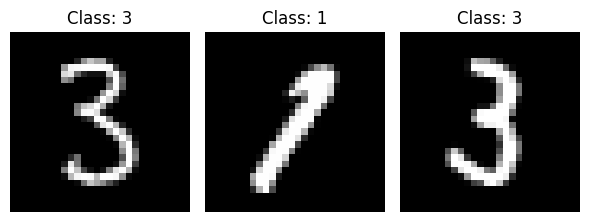

In [8]:
train_loader, val_loader, test_loader = load_data('mnist', batch_size=64)

names = {i: str(i) for i in range(10)}
visualize(train_loader, names, n=3, figsize=(6, 6))

In [48]:
device = 'cpu'
A = 5
model = mk_vae(10, 2, 784, A=A, device=device).to(device)

In [49]:
(x, y) = next(iter(train_loader))
x = x.to(device)
y = y.to(device)
x_recs, _, _, x_lows, cs, s_smps, c_smps, s_means, s_logvars, c_probs = model([x for _ in range(A)], 1)
cs = th.stack(cs)
cs.shape

torch.Size([5, 500, 10])

In [66]:
tic = time.time()
loss_naive = model.loss_naive(cs)
t1 = time.time() - tic

tic = time.time()
loss_vec = model.loss_vectorize(cs)
t2 = time.time() - tic

print(f"Naive loss: {loss_naive.item()}")
print(f"Vectorized loss: {loss_vec.item()}")
print(f"Relative error: {th.norm(loss_naive - loss_vec) / th.norm(loss_naive)}\n")


print(f"Naive loss computation took: {t1}s")
print(f"Vectorized loss computation took: {t2}s")
print(f"Speedup: {100 * (t1 - t2) / t1:.2f}%")

Naive loss: 71688.578125
Vectorized loss: 71688.5859375
Relative error: 1.0897830549083665e-07

Naive loss computation took: 0.003282785415649414s
Vectorized loss computation took: 0.0005891323089599609s
Speedup: 82.05%
